<a href="https://colab.research.google.com/github/evoreign/image-finder-revised/blob/main/Comparative_Analysis_of_SVM%2C_Random_Forest%2C_and_XGBoost_for_Depression_Risk_Prediction_Using_the_RHMCD_20_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport. Silakan upload dataset CSV Anda di sel berikutnya.")

Library berhasil diimport. Silakan upload dataset CSV Anda di sel berikutnya.


In [8]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"Dataset '{filename}' berhasil dimuat.")
print(f"Shape: {df.shape} (Baris: {df.shape[0]}, Kolom: {df.shape[1]})")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

display(df)

Saving mental_health_finaldata_1 (2).csv to mental_health_finaldata_1 (2) (1).csv
Dataset 'mental_health_finaldata_1 (2) (1).csv' berhasil dimuat.
Shape: (824, 13) (Baris: 824, Kolom: 13)


,Age,Gender,Occupation,Days_Indoors,Growing_Stress,Quarantine_Frustrations,Changes_Habits,Mental_Health_History,Weight_Change,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness
0,20-25,Female,Corporate,1-14 days,Yes,Yes,No,Yes,Yes,Medium,No,No,Yes
1,30-Above,Male,Others,31-60 days,Yes,Yes,Maybe,No,No,High,No,No,Yes
2,30-Above,Female,Student,Go out Every day,No,No,Yes,No,No,Medium,Yes,Maybe,No
3,25-30,Male,Others,1-14 days,Yes,No,Maybe,No,Maybe,Medium,No,Maybe,Yes
4,16-20,Female,Student,More than 2 months,Yes,Yes,Yes,No,Yes,Medium,Yes,Maybe,No
5,25-30,Male,Housewife,More than 2 months,No,Yes,Yes,Yes,Yes,Medium,No,Maybe,Maybe
6,16-20,Female,Business,Go out Every day,Yes,Yes,Maybe,No,Yes,Low,No,Maybe,Maybe
7,25-30,Female,Student,1-14 days,Yes,No,Maybe,Maybe,Maybe,High,No,No,Yes
8,30-Above,Male,Others,Go out Every day,Yes,Yes,Yes,No,Yes,Medium,Yes,Maybe,Maybe
9,20-25,Male,Corporate,Go out Every day,Maybe,Maybe,Yes,Yes,Yes,Low,No,Maybe,No


In [9]:
mappings = {
    'Age': {'16-20': 0, '20-25': 1, '25-30': 2, '30-Above': 3},
    'Gender': {'Female': 0, 'Male': 1},
    'Occupation': {'Corporate': 0, 'Others': 1, 'Student': 2, 'Housewife': 3, 'Business': 4},
    'Days_Indoors': {'Go out Every day': 0, '1-14 days': 1, '15-30 days': 2, '31-60 days': 3, 'More than 2 months': 4},
    'Growing_Stress': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Quarantine_Frustrations': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Changes_Habits': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Mental_Health_History': {'No': 0, 'Yes': 1},
    'Weight_Change': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Mood_Swings': {'Low': 0, 'Medium': 1, 'High': 2},
    'Coping_Struggles': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Work_Interest': {'No': 0, 'Yes': 1},
    'Social_Weakness': {'No': 0, 'Yes': 1}
}

df = df.replace(mappings)

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

df['Depression_Risk'] = ((df['Mood_Swings'] == 2) |
                         (df['Coping_Struggles'] == 2) |
                         (df['Social_Weakness'] == 1)).astype(int)


X = df.drop(['Mood_Swings', 'Coping_Struggles', 'Social_Weakness', 'Depression_Risk'], axis=1)
y = df['Depression_Risk']

print(f"Target 'Depression_Risk' berhasil dibuat.")
print(f"Distribusi Kelas: {y.value_counts().to_dict()}")

Target 'Depression_Risk' berhasil dibuat.
Distribusi Kelas: {1: 635, 0: 189}


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mappings = {
    'Age': {'16-20': 0, '20-25': 1, '25-30': 2, '30-Above': 3},
    'Gender': {'Female': 0, 'Male': 1},
    'Occupation': {'Corporate': 0, 'Others': 1, 'Student': 2, 'Housewife': 3, 'Business': 4},
    'Days_Indoors': {'Go out Every day': 0, '1-14 days': 1, '15-30 days': 2, '31-60 days': 3, 'More than 2 months': 4},
    'Growing_Stress': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Quarantine_Frustrations': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Changes_Habits': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Mental_Health_History': {'No': 0, 'Yes': 1},
    'Weight_Change': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Mood_Swings': {'Low': 0, 'Medium': 1, 'High': 2},
    'Coping_Struggles': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Work_Interest': {'No': 0, 'Yes': 1},
    'Social_Weakness': {'No': 0, 'Yes': 1}
}
df = df.replace(mappings)

df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(df.mean())

if 'Depression_Risk' not in df.columns:
    df['Depression_Risk'] = ((df['Mood_Swings'] == 2) |
                             (df['Coping_Struggles'] == 2) |
                             (df['Social_Weakness'] == 1)).astype(int)


cols_to_drop = ['Mood_Swings', 'Coping_Struggles', 'Social_Weakness', 'Depression_Risk']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
y = df['Depression_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil di-preprocess, di-split, & di-scale.")
print(f" X_train shape: {X_train_scaled.shape}")
print(f" X_test shape : {X_test_scaled.shape}")
print(f" Tipe data X_train: {X_train_scaled.dtype}")

Data berhasil di-preprocess, di-split, & di-scale.
 X_train shape: (659, 10)
 X_test shape : (165, 10)
 Tipe data X_train: float64


In [14]:
models = {
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, eval_metric='logloss', random_state=42, use_label_encoder=False)
}

results = {}

for name, model in models.items():
    print(f"\n🔹 Melatih model: {name}")
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc}

    print(classification_report(y_test, y_pred, target_names=['Low Risk (0)', 'High Risk (1)']))

df_results = pd.DataFrame(results).T
df_results = df_results.round(4)
print("\nTABEL PERBANDINGAN MODEL:")
display(df_results)


🔹 Melatih model: SVM
               precision    recall  f1-score   support

 Low Risk (0)       0.00      0.00      0.00        38
High Risk (1)       0.77      1.00      0.87       127

     accuracy                           0.77       165
    macro avg       0.38      0.50      0.43       165
 weighted avg       0.59      0.77      0.67       165


🔹 Melatih model: Random Forest
               precision    recall  f1-score   support

 Low Risk (0)       0.40      0.05      0.09        38
High Risk (1)       0.78      0.98      0.86       127

     accuracy                           0.76       165
    macro avg       0.59      0.51      0.48       165
 weighted avg       0.69      0.76      0.69       165


🔹 Melatih model: XGBoost
               precision    recall  f1-score   support

 Low Risk (0)       0.25      0.16      0.19        38
High Risk (1)       0.77      0.86      0.81       127

     accuracy                           0.70       165
    macro avg       0.51      0.

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
SVM,0.7697,0.7697,1.0000,0.8699,0.5686
Random Forest,0.7636,0.7750,0.9764,0.8641,0.5034
XGBoost,0.6970,0.7730,0.8583,0.8134,0.4608


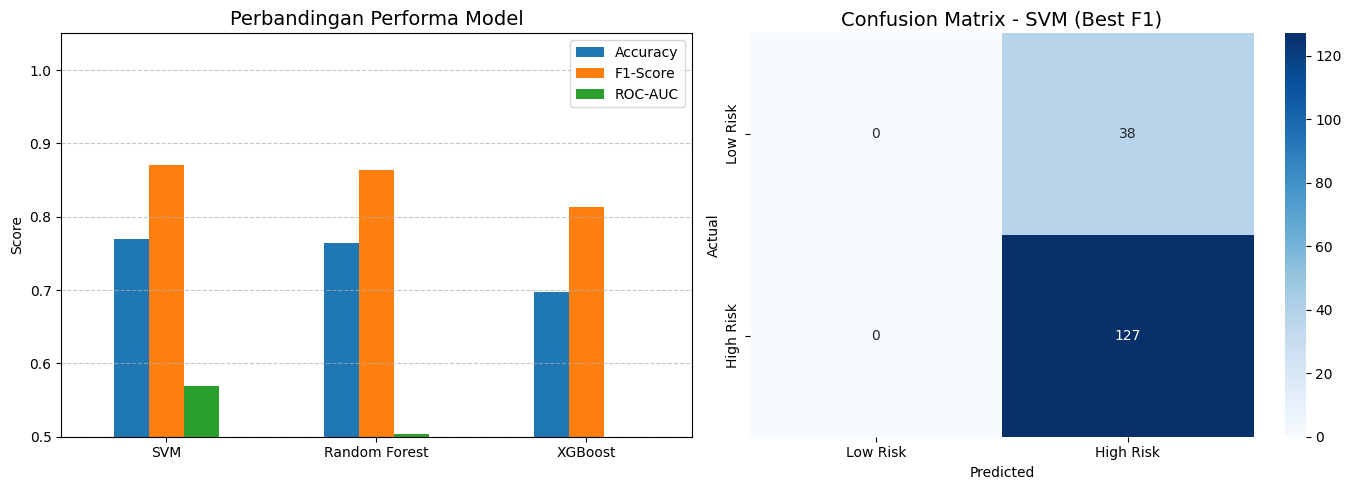

Model Terbaik berdasarkan F1-Score: SVM


In [13]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df_results[['Accuracy', 'F1-Score', 'ROC-AUC']].plot(kind='bar', ax=plt.gca(), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Perbandingan Performa Model', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.5, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

best_model = df_results['F1-Score'].idxmax()
best_model_obj = models[best_model]
best_model_obj.fit(X_train_scaled, y_train)
y_pred_best = best_model_obj.predict(X_test_scaled)

plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.title(f'Confusion Matrix - {best_model} (Best F1)', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

print(f"Model Terbaik berdasarkan F1-Score: {best_model}")